# 05 Noise, Detection, and Estimation

## Purpose

This notebook introduces the practical reality that every later sonar decision is made in uncertainty. The goal is to build intuition for additive noise, signal-to-noise ratio (SNR), threshold-based detection, and simple estimation from finite data.

## Prerequisites

- Notebook 01: Signals, Systems, and Sampling
- Notebook 02: Sinusoids, Complex Exponentials, and Phase
- Notebook 03: Fourier Transform and Spectral Intuition
- Notebook 04: Convolution, Filtering, and Matched Filters
- Basic comfort with averages, random variation, and plots

## Learning Objectives

By the end of this notebook, you should be able to:

- explain what additive noise means in sampled data,
- interpret SNR in both power-ratio and decibel form,
- explain why threshold-based detection creates false alarms and missed detections,
- connect matched-filter output distributions to detection tradeoffs,
- and describe why finite-data estimates become more reliable as more samples are used.


## New Terms In This Notebook

- **Additive noise**: unwanted random variation added to the signal of interest.
- **White Gaussian noise (WGN)**: a common idealized noise model with independent Gaussian samples and equal average power across frequency.
- **Average power**: for a discrete sequence, the average squared magnitude, often estimated as the mean of |x[n]|^2 over the observed samples.
- **Signal-to-noise ratio (SNR)**: the ratio of signal power to noise power.
- **Detection statistic**: a single number computed from the data and compared against a threshold to decide whether a signal is present.
- **Threshold**: the decision level above which we declare a detection.
- **False alarm**: declaring a detection when only noise is present.
- **Missed detection**: failing to declare a detection when the signal is actually present.
- **Probability of false alarm**: the fraction of noise-only trials that cross the threshold.
- **Probability of detection**: the fraction of signal-present trials that cross the threshold.
- **Estimator**: a rule that turns finite data into a numerical guess for an unknown quantity.
- **Bias**: the systematic difference between the average estimate and the true value.
- **Variance**: how much an estimate changes from trial to trial.
- **Monte Carlo simulation**: repeated random trials used to estimate probabilities or visualize statistical behavior.


## Big Picture

Notebook 04 showed that matched filters can create sharp peaks when a known waveform is present. This notebook asks the next practical question: what happens when the data is noisy, and how confident should we be in a detection or estimate?

That is the bridge from clean signal-processing intuition to real sensing systems. Later sonar notebooks will rely on these same ideas when we ask whether an echo is visible, whether a threshold is too aggressive, and how reliable any estimated delay or power value really is.


## Mathematical Definitions and Relevant Intuition

### Additive Noise Model

A simple noisy-observation model is

$$
y[n] = s[n] + w[n],
$$

where $s[n]$ is the signal of interest and $w[n]$ is noise.

The key intuition is that noise does not usually replace the signal. It competes with it. Detection becomes difficult when the random fluctuations in $w[n]$ are large enough to hide or imitate the structure in $s[n]$.

### Signal Power And Noise Power

For a finite discrete sequence, a simple average-power estimate is

$$
\widehat{P} = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2.
$$

This is the quantity we use in this notebook when we talk about signal power or noise power. It is just the average squared magnitude of the samples over the observation window.

### Signal-to-Noise Ratio (SNR)

If $P_s$ is average signal power and $P_n$ is average noise power, then

$$
\mathrm{SNR} = \frac{P_s}{P_n},
$$

and in decibels (dB),

$$
\mathrm{SNR}_{\mathrm{dB}} = 10 \log_{10}\!\left(\frac{P_s}{P_n}\right).
$$

Positive SNR means the signal power exceeds the noise power. Negative SNR does not mean the signal is gone. It means the noise power is larger, so structure is harder to see directly.

### Threshold Detection

A basic detection rule compares a statistic $T$ against a threshold $\gamma$:

$$
T \mathop{\gtrless}_{H_0}^{H_1} \gamma.
$$

Here $H_0$ means "noise only" and $H_1$ means "signal plus noise." Raising the threshold usually lowers false alarms but also lowers detection probability. Lowering the threshold does the opposite.

In the Monte Carlo example later in the notebook, the statistic is the peak matched-filter magnitude,

$$
T = \max_n |y_{MF}[n]|,
$$

so the detection decision is based on how large the strongest matched-filter response becomes in each trial.

### Finite-Data Estimation

An estimator uses finite samples to approximate an unknown quantity. For example, the sample mean and sample power are

$$
\hat{\mu} = \frac{1}{N} \sum_{n=0}^{N-1} x[n], \qquad
\widehat{P} = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2.
$$

The intuition is simple: with more samples, random fluctuations average out more effectively. That usually reduces estimator variance, even when the underlying randomness has not changed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import add_awgn, matched_filter, normalize
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal

set_plot_style()


def sample_power(values: np.ndarray) -> float:
    values = np.asarray(values)
    return float(np.mean(np.abs(values) ** 2))


def detection_rates(noise_only_stats: np.ndarray, signal_stats: np.ndarray, thresholds: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    p_fa = np.array([np.mean(noise_only_stats >= thr) for thr in thresholds], dtype=float)
    p_d = np.array([np.mean(signal_stats >= thr) for thr in thresholds], dtype=float)
    return p_fa, p_d


## Assumptions

- We use white Gaussian noise because it is simple and analytically familiar.
- We stay with one-dimensional, discrete-time examples.
- We focus on matched-filter magnitude as the detection statistic in the main examples.
- We use Monte Carlo simulation, meaning many repeated random trials, to build intuition rather than deriving every probability formula from first principles.


## Noise Changes What We Can See

For this first example, the known reference pulse is

`reference = [0.0, 0.4, 1.0, 0.7, 0.2, 0.0]`

and it is embedded once into a longer record. The figure below is meant to show how that same embedded pulse looks at three different SNR values. The top row shows the noisy received data, and the bottom row shows the matched-filter magnitude for the same trials.

The key lesson is that a signal can become hard to see in the raw data long before it becomes useless. The matched filter still accumulates aligned structure even when the waveform is visually hard to recognize.

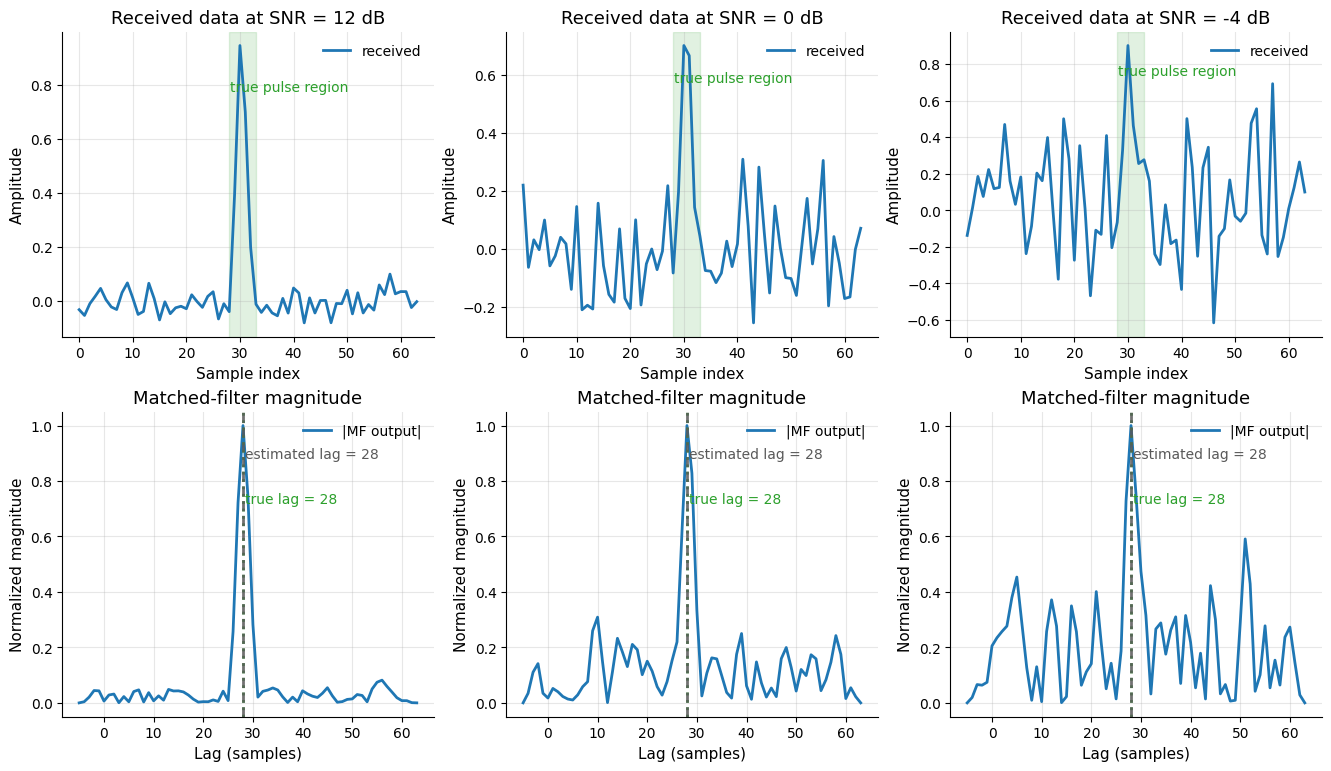

In [2]:
rng = np.random.default_rng(5)
reference = np.array([0.0, 0.4, 1.0, 0.7, 0.2, 0.0])
clean_received = np.zeros(64)
insert_at = 28
clean_received[insert_at : insert_at + len(reference)] = reference
snr_cases_db = [12.0, 0.0, -4.0]
true_lag = insert_at

fig, axes = make_figure(nrows=2, ncols=3, figsize=(13.2, 7.6), sharex=False)
for col, snr_case in enumerate(snr_cases_db):
    noisy = add_awgn(clean_received, snr_case, rng=rng)
    mf = matched_filter(noisy, reference, mode="full")
    lags = np.arange(-(len(reference) - 1), len(noisy))
    delay_est = int(lags[np.argmax(np.abs(mf))])

    plot_signal(np.arange(len(noisy)), noisy, ax=axes[0, col], title=f"Received data at SNR = {snr_case:.0f} dB", xlabel="Sample index", ylabel="Amplitude", label="received")
    axes[0, col].axvspan(insert_at, insert_at + len(reference) - 1, color="C2", alpha=0.14)
    axes[0, col].text(insert_at + 0.2, 0.82 * np.max(np.abs(noisy)), "true pulse region", color="C2")
    axes[0, col].legend(loc="upper right")

    plot_signal(lags, normalize(np.abs(mf)), ax=axes[1, col], title="Matched-filter magnitude", xlabel="Lag (samples)", ylabel="Normalized magnitude", label="|MF output|")
    axes[1, col].axvline(true_lag, color="C2", linestyle=":", alpha=0.9)
    axes[1, col].axvline(delay_est, color="0.35", linestyle="--", alpha=0.85)
    axes[1, col].text(delay_est + 0.4, 0.88, f"estimated lag = {delay_est}", color="0.35")
    axes[1, col].text(true_lag + 0.4, 0.72, f"true lag = {true_lag}", color="C2")
    axes[1, col].legend(loc="upper right")

plt.show()

At high SNR, the pulse is visible directly in the received data. As the SNR decreases, the raw waveform becomes much harder to interpret by eye, but the matched-filter output still produces a dominant peak at the true lag in these examples.

That is why detection systems usually do not operate by visual inspection of the raw samples. They transform the data into a statistic that separates the two hypotheses more effectively.

## Threshold Choice Creates False Alarms And Misses

The next figure is meant to show the core detection tradeoff. We run many noise-only trials and many signal-present trials, compute the peak matched-filter magnitude for each trial, and compare those peak values against a threshold.

So the plotted detection statistic is not the whole matched-filter curve. It is one number per trial: the largest matched-filter magnitude produced anywhere in that trial. If the threshold is too low, many noise-only trials cross it and create false alarms. If the threshold is too high, many signal-present trials fail to cross it and create missed detections.

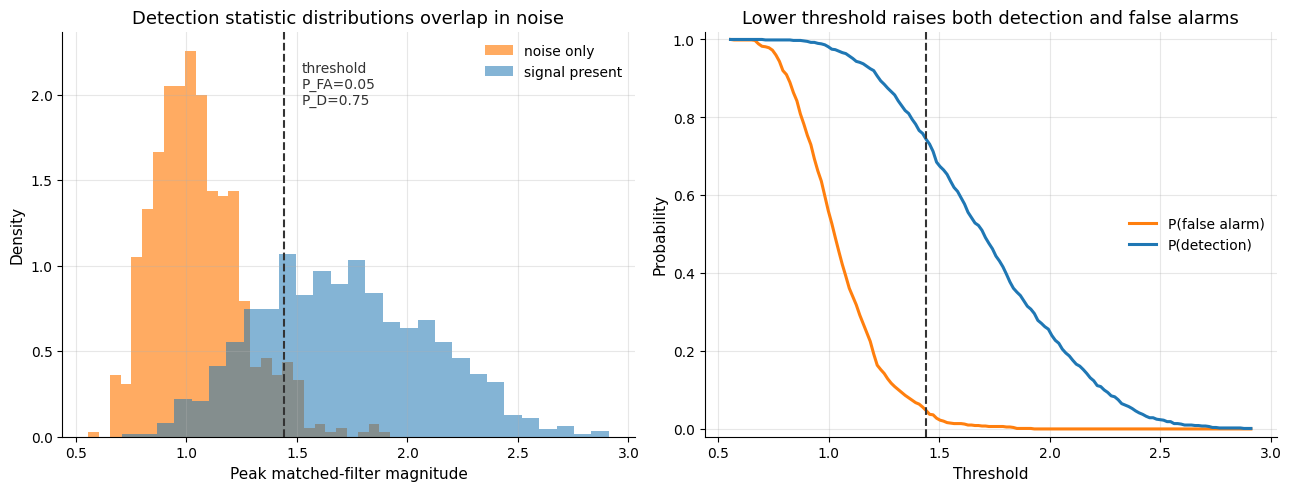

Example threshold: 1.439
Empirical P(false alarm): 0.050
Empirical P(detection): 0.746


In [3]:
rng = np.random.default_rng(12)
num_trials = 800
snr_detect_db = -6.0
record_len = 64
insert_at = 28

signal_clean = np.zeros(record_len)
signal_clean[insert_at : insert_at + len(reference)] = reference
signal_power = sample_power(signal_clean)
noise_power = signal_power / (10.0 ** (snr_detect_db / 10.0))
noise_std = np.sqrt(noise_power)

noise_only_stats = []
signal_present_stats = []
for _ in range(num_trials):
    noise_only = rng.normal(scale=noise_std, size=record_len)
    signal_present = signal_clean + rng.normal(scale=noise_std, size=record_len)

    noise_only_stats.append(np.max(np.abs(matched_filter(noise_only, reference, mode="full"))))
    signal_present_stats.append(np.max(np.abs(matched_filter(signal_present, reference, mode="full"))))

noise_only_stats = np.array(noise_only_stats)
signal_present_stats = np.array(signal_present_stats)
thresholds = np.linspace(min(noise_only_stats.min(), signal_present_stats.min()), max(noise_only_stats.max(), signal_present_stats.max()), 150)
p_fa, p_d = detection_rates(noise_only_stats, signal_present_stats, thresholds)
example_threshold = np.quantile(noise_only_stats, 0.95)
example_p_fa = float(np.mean(noise_only_stats >= example_threshold))
example_p_d = float(np.mean(signal_present_stats >= example_threshold))

fig, axes = make_figure(nrows=1, ncols=2, figsize=(12.8, 4.8), sharex=False)
axes[0].hist(noise_only_stats, bins=28, alpha=0.65, label="noise only", color="C1", density=True)
axes[0].hist(signal_present_stats, bins=28, alpha=0.55, label="signal present", color="C0", density=True)
axes[0].axvline(example_threshold, color="0.2", linestyle="--", linewidth=1.5)
axes[0].set_title("Detection statistic distributions overlap in noise")
axes[0].set_xlabel("Peak matched-filter magnitude")
axes[0].set_ylabel("Density")
axes[0].legend(loc="upper right")
axes[0].text(example_threshold + 0.08, axes[0].get_ylim()[1] * 0.82, f"threshold\nP_FA={example_p_fa:.2f}\nP_D={example_p_d:.2f}", color="0.2")

axes[1].plot(thresholds, p_fa, color="C1", linewidth=2.2, label="P(false alarm)")
axes[1].plot(thresholds, p_d, color="C0", linewidth=2.2, label="P(detection)")
axes[1].axvline(example_threshold, color="0.2", linestyle="--", linewidth=1.5)
axes[1].set_title("Lower threshold raises both detection and false alarms")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(loc="center right")

plt.show()

print(f"Example threshold: {example_threshold:.3f}")
print(f"Empirical P(false alarm): {example_p_fa:.3f}")
print(f"Empirical P(detection): {example_p_d:.3f}")

The overlap between the two distributions is the practical problem. If they were completely separated, one threshold would produce both zero false alarms and perfect detection. In noise, that ideal separation is usually unavailable.

The right-hand panel gives the same tradeoff in a different view. As the threshold moves left, the detector becomes more willing to declare a signal, so both detection probability and false-alarm probability rise. As the threshold moves right, both fall, which is why threshold selection is always an engineering compromise rather than a purely mathematical one.

## Finite Data Makes Estimates Uncertain

The figure below is meant to show that even a simple estimator, such as average noise power, varies from trial to trial when only a finite number of samples is available.

We compare short and long observation windows using the same underlying white-noise process. The true noise power is the same in both cases, but the shorter estimate fluctuates much more. The second panel then shows one running estimate so the student can see that the estimate does not converge smoothly or monotonically. It wanders before settling closer to the true value.

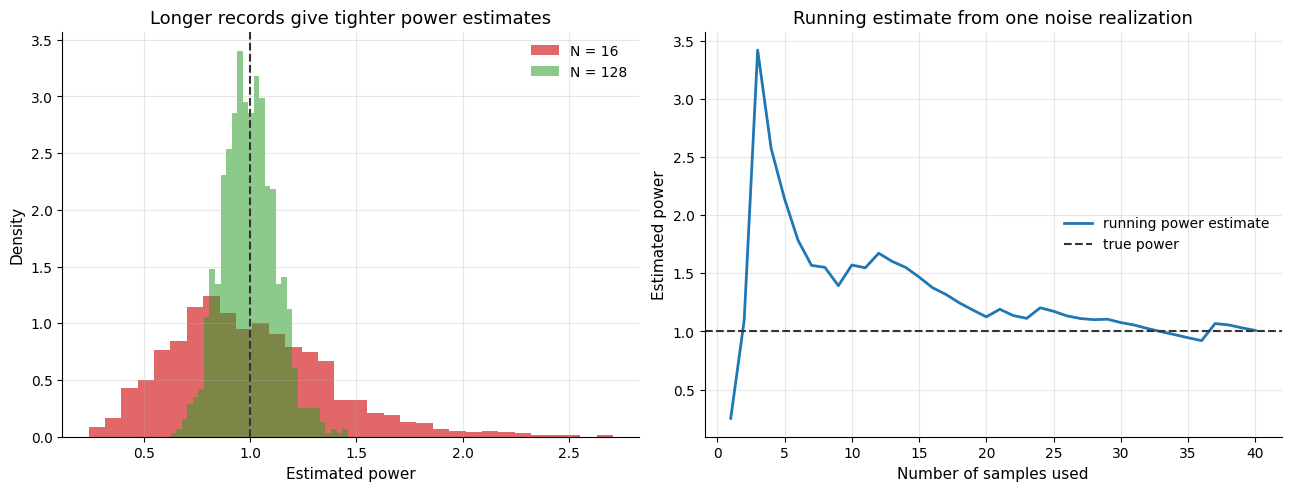

True noise power: 1.000
Mean short-window estimate: 0.998
Mean long-window estimate: 0.995
Std. dev. short-window estimate: 0.373
Std. dev. long-window estimate: 0.125


In [4]:
rng = np.random.default_rng(21)
num_trials = 1200
short_n = 16
long_n = 128
true_noise_std = 1.0
true_power = true_noise_std**2

short_estimates = []
long_estimates = []
for _ in range(num_trials):
    short_noise = rng.normal(scale=true_noise_std, size=short_n)
    long_noise = rng.normal(scale=true_noise_std, size=long_n)
    short_estimates.append(sample_power(short_noise))
    long_estimates.append(sample_power(long_noise))

short_estimates = np.array(short_estimates)
long_estimates = np.array(long_estimates)

fig, axes = make_figure(nrows=1, ncols=2, figsize=(12.8, 4.8), sharex=False)
axes[0].hist(short_estimates, bins=32, alpha=0.7, color="C3", density=True, label=f"N = {short_n}")
axes[0].hist(long_estimates, bins=32, alpha=0.55, color="C2", density=True, label=f"N = {long_n}")
axes[0].axvline(true_power, color="0.2", linestyle="--", linewidth=1.5)
axes[0].set_title("Longer records give tighter power estimates")
axes[0].set_xlabel("Estimated power")
axes[0].set_ylabel("Density")
axes[0].legend(loc="upper right")

trial_index = np.arange(1, 41)
example_noise = rng.normal(scale=true_noise_std, size=40)
running_est = np.array([sample_power(example_noise[:k]) for k in trial_index])
plot_signal(trial_index, running_est, ax=axes[1], title="Running estimate from one noise realization", xlabel="Number of samples used", ylabel="Estimated power", label="running power estimate")
axes[1].axhline(true_power, color="0.2", linestyle="--", linewidth=1.5, label="true power")
axes[1].legend(loc="center right")

plt.show()

print(f"True noise power: {true_power:.3f}")
print(f"Mean short-window estimate: {np.mean(short_estimates):.3f}")
print(f"Mean long-window estimate: {np.mean(long_estimates):.3f}")
print(f"Std. dev. short-window estimate: {np.std(short_estimates):.3f}")
print(f"Std. dev. long-window estimate: {np.std(long_estimates):.3f}")

The averages of the short and long estimates are both close to the true power, so the estimator is not badly biased in this example. The difference is variance: the short-window estimate wanders much more.

That is the essential finite-data lesson. More data does not guarantee perfection, but it usually makes simple estimates more stable.


## Tradeoffs And Limitations

Several practical tradeoffs are visible in this notebook:

- Lower thresholds increase detection probability but also increase false alarms.
- Higher thresholds reduce false alarms but make weak signals easier to miss.
- Matched filtering improves detectability, but it still depends on having a good waveform model.
- Longer records usually improve estimate stability, but they also require more observation time and may blur time variation.

This notebook also leaves out several important realities:

- colored or non-Gaussian noise,
- adaptive thresholds,
- model mismatch beyond simple additive noise,
- and formal detector design such as Neyman-Pearson or Bayesian decision rules.


## Recap

- Additive noise competes with the signal rather than simply erasing it.
- SNR describes the signal-to-noise balance and is often expressed in dB.
- Threshold detection always trades false alarms against missed detections.
- Matched-filter peaks remain useful even when raw waveforms are visually ambiguous.
- Finite-data estimates become more stable as more samples are used.



## Suggested Next Questions

- How does propagation delay map directly to target range in sonar?
- How should we think about transmit time, echo return time, and receive-window timing together?
- How does a matched-filter delay estimate become a physical range estimate?

The next notebook turns those questions into sonar-specific propagation and time-of-flight intuition.
